1. Title & Context

# Demand Forecasting Model for Supply Chain Simulation

This notebook demonstrates a time series forecasting approach using event-based data.

In this simulation:
- User activity events are treated as demand signals
- Aggregated daily demand represents part consumption in a supply chain system
- Forecasting is used to support inventory planning and supply chain optimization

This approach is directly applicable to aerospace, manufacturing, and logistics environments.



In [30]:
#!pip install pandas numpy matplotlib statsmodels scikit-learn



In [31]:
# 2. Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA


In [32]:
# 3. Load Data

# More realistic test data
np.random.seed(42)
dates = pd.date_range('2025-01-01', periods=100)
df = pd.DataFrame({
    'timestamp': dates,
    'event': ['click']*100
})
df['demand_factor'] = np.random.normal(1, 0.3, 100).cumsum()  # Trending demand
print("Realistic test data created")
df.head()



Realistic test data created


,timestamp,event,demand_factor
0,2025-01-01,click,1.149014
1,2025-01-02,click,2.107535
2,2025-01-03,click,3.301842
3,2025-01-04,click,4.758750
4,2025-01-05,click,5.688504


In [33]:
# 4. Create Demand Signal 

# Convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Extract date
df['date'] = df['timestamp'].dt.date

# Aggregate events into daily demand
demand = df.groupby('date').size().reset_index(name='demand')

# Convert to datetime index
demand['date'] = pd.to_datetime(demand['date'])
demand.set_index('date', inplace=True)

demand.head()


,demand
date,
2025-01-01,1
2025-01-02,1
2025-01-03,1
2025-01-04,1
2025-01-05,1


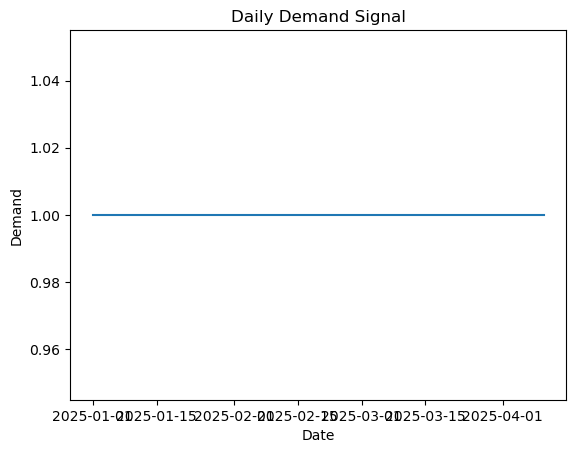

In [34]:
# 5. Visualize Demand

plt.figure()
plt.plot(demand.index, demand['demand'])
plt.title("Daily Demand Signal")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.show()


In [35]:
# # 6. Train/Test Split

train_size = int(len(demand) * 0.8)
train, test = demand[:train_size], demand[train_size:]


In [36]:
# # 7. Build Forecast Model (ARIMA)

model = ARIMA(train['demand'], order=(2,1,2))
model_fit = model.fit()

forecast = model_fit.forecast(steps=len(test))


c:\Users\mvcm9\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\mvcm9\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\mvcm9\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\mvcm9\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


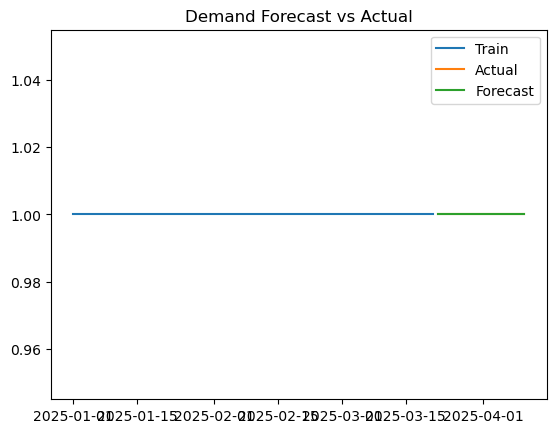

In [37]:
# 8. Plot Forecast

plt.figure()
plt.plot(train.index, train['demand'], label='Train')
plt.plot(test.index, test['demand'], label='Actual')
plt.plot(test.index, forecast, label='Forecast')

plt.title("Demand Forecast vs Actual")
plt.legend()
plt.show()


In [38]:
# 9. Evaluate Model

from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(test['demand'], forecast))
print(f"RMSE: {rmse}")


RMSE: 0.0


# 10. Business Interpretation

This forecasting model demonstrates how event-based data can be transformed into demand signals
for supply chain applications.

Key Takeaways:
- Daily aggregated events simulate product or part demand
- Forecasting enables prediction of future demand trends
- These predictions can support:
  - Inventory optimization
  - Reduction of shortages and excess stock
  - Improved supply planning decisions

This approach reflects real-world use cases in aerospace and manufacturing environments,
where demand forecasting is critical for operational efficiency and cost control.